![logo](https://climate.copernicus.eu/sites/default/files/2025-03/logoline_c3s.png)

# Tutorial on comparing CARRA and ERA5 2m temperature data 

**Last updated:** 2026-07-29

**This notebook can be run on free online platforms, such as Binder, Kaggle and Colab, or they can be accessed from GitHub. The links to run this notebook in these environments are provided here, but please note they are not supported by ECMWF.**

[![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/ecmwf-training/c3s-training-submodule-reanalysis/develop?labpath=reanalysis-carra-era5.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-training/c3s-training-submodule-reanalysis/blob/develop/reanalysis-carra-era5.ipynb)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/c3s-training-submodule-reanalysis/blob/develop/reanalysis-carra-era5.ipynb)
[![github](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/ecmwf-training/c3s-training-submodule-reanalysis/blob/develop/reanalysis-carra-era5.ipynb)

## Introduction

Understanding global and regional atmospheric conditions is critical for climate research, weather forecasting, and environmental monitoring. Reanalysis datasets like ERA5 (ECMWF's fifth-generation global reanalysis) and CARRA (Copernicus Arctic Regional Reanalysis) provide high-quality, gridded estimates of atmospheric variables, enabling scientists to study past weather and climate patterns. Both datasets can be found in, and are freely accessible through, the [Copernicus Climate Data Store (CDS)](https://cds.climate.copernicus.eu/#!/home).

Both datasets enhance our insights into Earth's systems, but they are different in several aspects. ERA5 offers a comprehensive global perspective with a resolution of approximately 31 km. Meanwhile CARRA is regional and tailored for the Arctic region, delivering higher spatial resolution (~2.5 km) and specialized insights into polar processes, that make it particularly adequate for studying the Arctic’s unique climate dynamics.

In this tutorial, we focus on comparing 2m temperature data from both datasets. There are 5 CARRA entries available in the CDS: sub-daily data for [single](https://cds.climate.copernicus.eu/datasets/reanalysis-carra-single-levels?tab=overview), [height](https://cds.climate.copernicus.eu/datasets/reanalysis-carra-height-levels?tab=overview), [pressure](https://cds.climate.copernicus.eu/datasets/reanalysis-carra-pressure-levels?tab=overview) and [model levels](https://cds.climate.copernicus.eu/datasets/reanalysis-carra-model-levels?tab=overview) and data aggregated for a [day or month](https://cds.climate.copernicus.eu/datasets/reanalysis-carra-means?tab=overview). Practical details of the CARRA dataset are available in [the documentation](https://confluence.ecmwf.int/x/K0s7E). Meanwhile, the complete ERA5 portfolio of datasets is availble at [ERA5](https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-complete?tab=overview).

Here the CARRA single level entry is selected for the 2m temperature. The ERA5 dataset, available in full via the Copernicus Climate Data Store (CDS), serves as our global benchmark. By comparing these datasets, you will get an awareness of their strengths, limitations, and potential applications — whether for validating regional models, assessing climate trends, or supporting decision-making in Arctic-sensitive sectors.


## Learning objectives 🎯

This tutorial demonstrates how to access and retrieve CARRA and ERA5 data and how to inter-compare them on the CARRA domain. CARRA is a high resolution (2.5 km) regional re-analysis which gives added details compared to the ERA5 global reanalysis. These details can be visualised by comparing the plots of CARRA and ERA5 data, and particularly when the differences of the two datasets are plotted together. By the end, you will have:
- Accessed and downloaded 2m temperature data from both the ERA5 and CARRA data, interacting with the Copernicus Climate Data Store using Python code.
- Prepared the data for an inter-comparison, by interpolating them to the same grid and computing monthly means.
- Created engaging map-like visuals (plots), that emphasize the differences between the two datasets.


## Prepare your environment

The first thing we need to do, is make sure you are ready to run the code while working through this notebook. There are some simple steps you need to do to get yourself set up.

### Set up CDSAPI and your credentials

The code below will ensure that the `cdsapi` package is installed. If you have not setup your `~/.cdsapirc` file with your credentials, you can replace `None` with your credentials that can be found on the [how to api](https://cds.climate.copernicus.eu/how-to-api) page (you will need to log in to see your credentials).

In [1]:
!pip install -q cdsapi
# If you have already setup your .cdsapirc file you can leave this as None
cdsapi_key = None
cdsapi_url = None

### (Install and) Import libraries

To run the code in this tutorial please install any missing packages here.

*Please note that the package xESMF is not in the environment file, but can be installed following the instructions [here](https://xesmf.readthedocs.io/en/stable/).*

In [2]:
import os
import cdsapi
import earthkit.plots as ekp
import cartopy.crs as ccrs
import xarray as xr

# Package to interpolate ERA5 data to the CARRA grid
import xesmf as xe

### Specify data directory

In [3]:
# Directory to store data
DATADIR = "./data_dir/"
# Create this directory if it doesn't exist
os.makedirs(DATADIR, exist_ok=True)


period = "202403"  # the period to plot
fCARRA = os.path.join(DATADIR, "carra_T2m_an_" + period + ".grb")
fERA5 = os.path.join(DATADIR, "era5_T2m_an_" + period + ".grb")

## Explore data

The source code will download a specific month. By specifying the start and end date below, one can easily download longer periods. We are selecting 2m temperature, which is in the single level CDS entry. 
Here, we download the 3-hourly analysis time steps, and the data will be stored in a specified file.

For this tutorial we just request one month of data, March 2024. Note that we define a sub-domain to use for the ERA5 request.



In [4]:
# Here one specifies the domain, year and period to download
yearStart = 2024  # first year to download
yearEnd = 2024  # last year to download
monthStart = 3  # first month to download
monthEnd = 3  # last month to download
days = [
    str(i).zfill(2) for i in range(1, 31)
]  # the list of days to download. Adapt day number for other months
domain = (
    "west_domain"  # the domain to select. Use "east_domain" for the CARRA-East domain
)
period = "202403"  # the period to plot

# Below a polygon to limit the area downloaded from ERA5, otherwise it will download the whole world
area_for_era5 = [
    90,
    -110,
    55,
    40,
]  # WEST domain polygon, format: North,West,South,East corners
# area_for_era5 = [85,0,60,50]: EAST domain polygon

### Download the data

#### Define helper functions to formulate the CDS data request

The functions below allow repeated CDS API requests to be made, in case multiple requests are required to retrieve high volumes of data. In this case we are only requesting one month.

In [5]:
# Open the CDS client
c = cdsapi.Client(url=cdsapi_url, key=cdsapi_key)

2026-07-29 12:00:26,416 CRITICAL [2025-09-30T00:00:00Z] This is an experimental and unsupported instance of the data store, not to be used in a production environment. For production environment go to [here](https://cds.climate.copernicus.eu/).
2026-07-29 12:00:26,416 INFO [2024-07-18T00:00:00Z] Remember that you need to have an ECMWF account to use CDS-Beta. **Your existing CDS credentials will not work in CDS-Beta!**
2026-07-29 12:00:26,417 WARNING [2024-06-16T00:00:00Z] **BETA version** of the new CDS. Your [feedback](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202) is very useful for us. **Please notice** that access to the system might suffer some disruptions due to evolving updates.
2026-07-29 12:00:26,417 WARNING [2024-06-16T00:00:00Z] Check our [informative page](https://confluence.ecmwf.int/x/uINmFw) to best prepare yourself to use CDS-Beta.
2026-07-29 12:00:26,418 WARNING [2024-06-16T00:00:00Z] CDS API syntax is changed and some keys or parameter names may hav

In [6]:
# Define a helper function to download the data
# Note that the time is hardcoded since we are selecting
# all possible available times.
def fetch_month_carra(month, year, days, domain, fout):
    c.retrieve(
        "reanalysis-carra-single-levels",
        {
            "format": "grib",
            "domain": domain,
            "level_type": "surface_or_atmosphere",
            "variable": "2m_temperature",
            "product_type": "analysis",
            "year": year,
            "month": f"{month:02d}",
            "day": days,
            "time": [
                "00:00",
                "03:00",
                "06:00",
                "09:00",
                "12:00",
                "15:00",
                "18:00",
                "21:00",
            ],
        },
        fout,
    )

In [7]:
# Help function to download ERA5 data
def fetch_month_era5(month, year, days, area, fout):
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": "2m_temperature",
            "year": str(year),
            "month": f"{month:02d}",
            "day": days,
            "time": [
                "00:00",
                "03:00",
                "06:00",
                "09:00",
                "12:00",
                "15:00",
                "18:00",
                "21:00",
            ],
            "area": area,
            "format": "grib",
        },
        fout,
    )

#### Request the CARRA-West data

The loops below may be useful if you are requesting a large volume of data, in this case one month is being requested.

In [8]:
# Loop through the period selected (in this example only 2024 03 is requested)
for year in list(range(yearStart, yearEnd + 1)):
    for month in list(range(1, 13)):
        if year == yearStart and month < monthStart:
            # Before the start date.
            continue
        if year == yearEnd and month > monthEnd:
            # After end date.
            break

        print("CARRA data will be fetched for ", year, month)
        print(
            "This will take a few minutes, depending on the data size (here ~621 MB for west, ~357 MB for east case)"
        )
        if not os.path.exists(fCARRA):
            fetch_month_carra(month, year, days, domain, fCARRA)

CARRA data will be fetched for  2024 3
This will take a few minutes, depending on the data size (here ~621 MB for west, ~357 MB for east case)


#### Request the ERA5 data

In [9]:
# Loop through the period selected
for year in list(range(yearStart, yearEnd + 1)):
    for month in list(range(1, 13)):
        if year == yearStart and month < monthStart:
            # Before the start date.
            continue
        if year == yearEnd and month > monthEnd:
            # After end date.
            break

        print("ERA5 data will be fetched for ", year, month)
        print(
            "This will take a few minutes, depending on the data size (here ~39 MB for west area)"
        )
        if not os.path.exists(fERA5):
            fetch_month_era5(month, year, days, area_for_era5, fERA5)

ERA5 data will be fetched for  2024 3
This will take a few minutes, depending on the data size (here ~39 MB for west area)


## Plotting the CARRA and ERA5 data

### Interpolate data to a common grid
Before plotting the two datasets we want to have them on the same grid. For this we interpolate ERA5 to the CARRA (CARRA-West) grid. Below we use [xesmf](https://xesmf.readthedocs.io/en/stable/). The interpolation/projection can also be done using the [pyresample](https://pyresample.readthedocs.io/en/latest/howtos/swath.html) library, or [CDO](https://code.mpimet.mpg.de/projects/cdo).

Inspect the ERA5 datacube.

In [10]:
fERA5

'./data_dir/era5_T2m_an_202403.grb'

In [11]:
ERA5 = xr.open_dataset(fERA5)
ERA5

Ignoring index file './data_dir/era5_T2m_an_202403.grb.5b7b6.idx' older than GRIB file


<xarray.Dataset> Size: 81MB
Dimensions:     (time: 240, latitude: 141, longitude: 601)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2024-03-01 ... 2024-03-30T21:00:00
    valid_time  (time) datetime64[ns] 2kB ...
  * latitude    (latitude) float64 1kB 90.0 89.75 89.5 89.25 ... 55.5 55.25 55.0
  * longitude   (longitude) float64 5kB -110.0 -109.8 -109.5 ... 39.5 39.75 40.0
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    t2m         (time, latitude, longitude) float32 81MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-29T12:00 GRIB to CDM+CF via cfgrib-0.9.1...

Inspect the CARRA datacube.

In [12]:
CARRA = xr.open_dataset(fCARRA)
CARRA

<xarray.Dataset> Size: 1GB
Dimensions:            (time: 240, y: 1269, x: 1069)
Coordinates:
  * time               (time) datetime64[ns] 2kB 2024-03-01 ... 2024-03-30T21...
    valid_time         (time) datetime64[ns] 2kB ...
    latitude           (y, x) float64 11MB ...
    longitude          (y, x) float64 11MB ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    t2m                (time, y, x) float32 1GB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             enmi
    GRIB_centreDescription:  Oslo
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Oslo
    history:                 2026-07-29T12:00 GRIB to CDM+CF via cfgrib-0.9.1...

We remove some additional coordinates in the datasets, to ease the regridding operation.

In [13]:
ERA5 = ERA5.drop_vars(["number", "step", "valid_time", "surface"])
CARRA = CARRA.drop_vars(["step", "valid_time", "heightAboveGround"])

Now use xesmf bilinear interpolation to construct a regridder object and apply it to the ERA5 data.

In [14]:
# Create regridder using xesmf bilinear interpolation
regridder = xe.Regridder(ERA5, CARRA, "bilinear")
# Regrid the data
print("regridding the ERA5 data")
ERA5_CARRA = regridder(ERA5)
print("done")

regridding the ERA5 data
done


Check the format of the output and save it.

In [15]:
ERA5_CARRA
fERA5_CARRA_grid = os.path.join(DATADIR, "era5_t2m_" + period + "_CARRA_grid.nc")
ERA5_CARRA.to_netcdf(fERA5_CARRA_grid)

### Plotting the data
Compute the mean 2m temperature over the whole month. First, we open the data sets using xarray and then calculate their mean over the whole month, prepare the dataset for plotting on a latitude/longitude grid, and the temperature units (from Kelvin to degrees Celsius).


In [16]:
# Open the data sets to plot using xarray

# Open Datasets
CARRA = xr.open_dataset(fCARRA)
CARRA = CARRA.drop_vars(["step", "valid_time", "heightAboveGround"])
ERA5 = xr.open_dataset(fERA5_CARRA_grid)

# Compute monthly mean
print("Computing the mean for CARRA and ERA5...")
CARRA_mean = CARRA.mean("time", keep_attrs=True)
ERA5_mean = ERA5.mean("time", keep_attrs=True)
print("Done.")

# Change longitudes from 0-360 to -180 to 180, needed for the plotting
CARRA_mean = CARRA_mean.assign_coords(
    longitude=(((CARRA_mean.longitude + 180) % 360) - 180)
)
ERA5_mean = ERA5_mean.assign_coords(longitude=CARRA_mean.longitude)

# Change unit from K to C and add the unit to the attributes
CARRA_mean_C = CARRA_mean - 273.15
CARRA_mean_C = CARRA_mean_C.assign_attrs(CARRA_mean.attrs)
CARRA_mean_C.attrs["units"] = "deg C"
ERA5_mean_C = ERA5_mean - 273.15
ERA5_mean_C = ERA5_mean_C.assign_attrs(ERA5_mean.attrs)
ERA5_mean_C.attrs["units"] = "deg C"

Computing the mean for CARRA and ERA5...
Done.


#### Plot for CARRA

We fix the scale of each of the separate CARRA and ERA5 plots to the range from -30 to 30 degrees Celsius. This ensures the two figures can be compared directly. 

The plot below shows the CARRA 2m temperature monthly mean (March 2024) values for the CARRA-West domain.

Plotting CARRA mean surface temperature


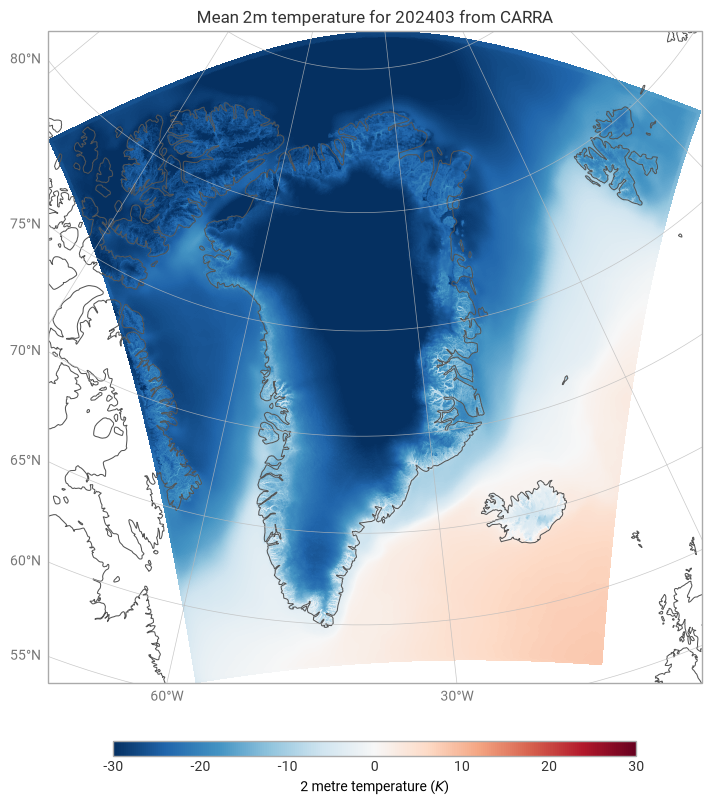

In [17]:
print("Plotting CARRA mean surface temperature")
map = ekp.Map(crs=ccrs.LambertConformal(central_latitude=70.0, central_longitude=-40.0))
map.pcolormesh(
    CARRA_mean_C.t2m,
    x="longitude",
    y="latitude",
    colors="RdBu_r",
    vmin=-30,
    vmax=30,
)
map.title(f"Mean 2m temperature for {period} from CARRA")
map.coastlines()
map.gridlines()
map.legend()
map.show()

#### Plot for ERA5

The plot shows ERA5 2m temperature monthly mean (March 2024) values on the CARRA-West domain. 

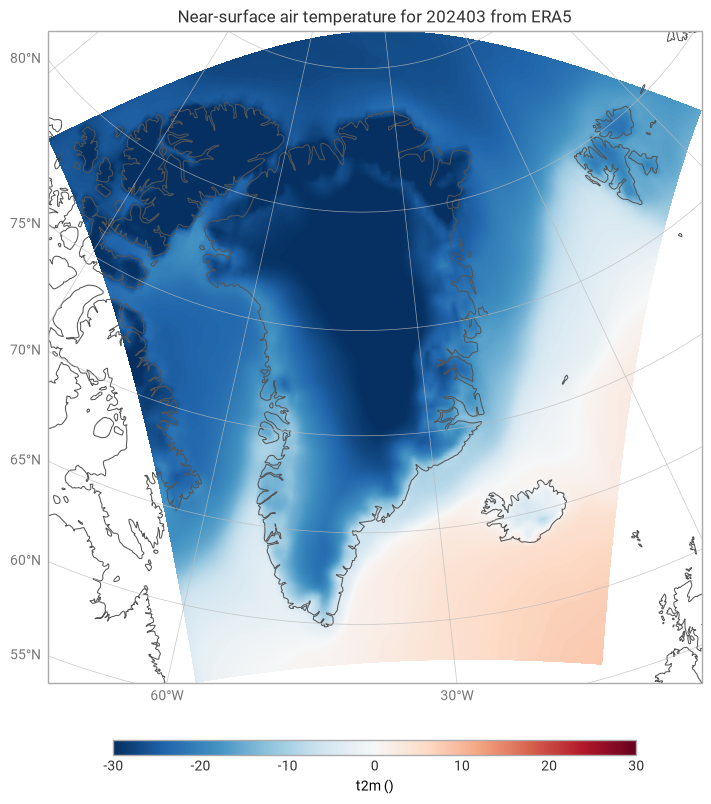

In [18]:
map = ekp.Map(crs=ccrs.LambertConformal(central_latitude=70.0, central_longitude=-40.0))
map.pcolormesh(
    ERA5_mean_C.t2m,
    x="longitude",
    y="latitude",
    colors="RdBu_r",
    vmin=-30,
    vmax=30,
)
map.title(f"Near-surface air temperature for {period} from ERA5")
map.coastlines()
map.gridlines()
map.legend()
map.show()

#### Plot the difference between CARRA and ERA5

Note that the differences are computed in the plotting command itself. Here we plot the difference with a range of -10 to 10 degrees Celsius.

The plot shows the 2m monthly mean (March 2024) 2m temperature difference between CARRA and ERA5 over the CARRA-West domain.

Plotting the difference CARRA - ERA5


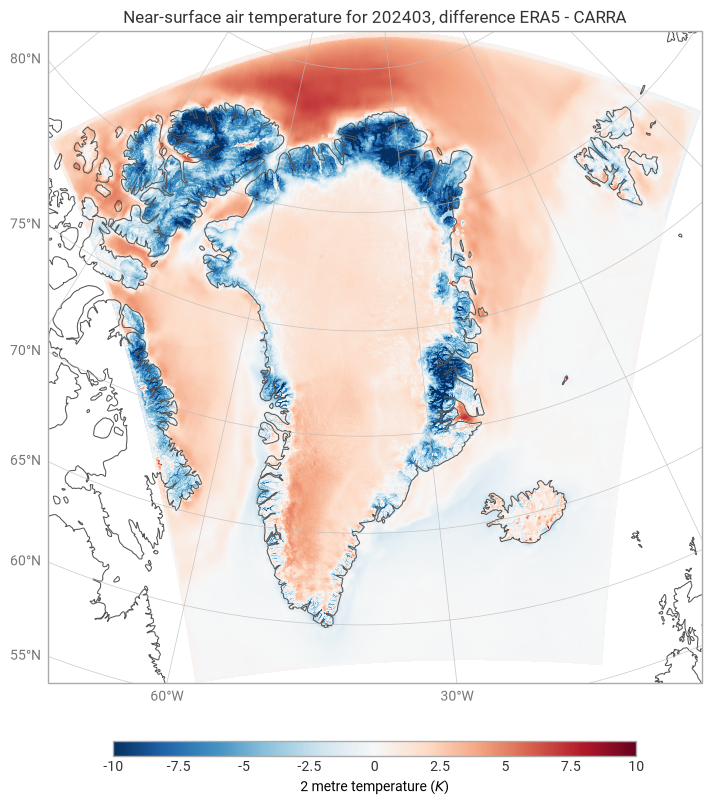

In [19]:
print("Plotting the difference CARRA - ERA5")

map = ekp.Map(crs=ccrs.LambertConformal(central_latitude=70.0, central_longitude=-40.0))
map.pcolormesh(
    ERA5_mean_C.t2m - CARRA_mean_C.t2m,
    x="longitude",
    y="latitude",
    colors="RdBu_r",
    vmin=-10,
    vmax=10,
)
map.title(f"Near-surface air temperature for {period}, difference ERA5 - CARRA")
map.coastlines()
map.gridlines()
map.legend()
map.show()

## Take home messages 📌

- CARRA and ERA5 data, while broadly similar, contain subtle, but important differences in values due to their spatial scope. These differences are important to note.

- Note the differences visible between CARRA and ERA5, especially over coastal areas and over complex orography (mountainous terrain) where the high resolution CARRA data can provide additional information compared to ERA5, such as for instance the significantly lower temperatures at higher elevations near the coasts.

- The differences in northern ocean areas likely come from the better description of sea-ice characteristics by CARRA. 

- The differences are much easier to see in the difference plot above, however they can also be recognised in the individual plots as finer details in the CARRA plot.